In [ ]:
# Aşama 1: Veri Yükleme ve Temizleme

In [ ]:
from google.colab import files
yuklenen = files.upload()

Saving TARP.csv to TARP.csv


In [ ]:
# Aşama 2: Keşifçi Veri Analizi (EDA)

In [ ]:
import pandas as pd

dosya_adi = list(yuklenen.keys())[0]
df = pd.read_csv(dosya_adi)

print(df.shape)
print(df.columns.tolist())
df.head()

(100000, 15)
['Soil Moisture', 'Temperature', ' Soil Humidity', 'Time', 'Air temperature (C)', 'Wind speed (Km/h)', 'Air humidity (%)', 'Wind gust (Km/h)', 'Pressure (KPa)', 'ph', 'rainfall', 'N', 'P', 'K', 'Status']


,Soil Moisture,Temperature,Soil Humidity,Time,Air temperature (C),Wind speed (Km/h),Air humidity (%),Wind gust (Km/h),Pressure (KPa),ph,rainfall,N,P,K,Status
0,54,22,70,21,19.52,2.13,55.04,6.30,101.50,6.502985,202.935536,90.0,42.0,43.0,ON
1,12,20,40,104,19.49,2.01,55.17,10.46,101.50,7.038096,226.655537,85.0,58.0,41.0,OFF
2,34,26,35,62,19.47,1.90,55.30,14.63,101.51,7.840207,263.964248,60.0,55.0,44.0,ON
3,7,44,44,93,19.54,2.28,54.20,16.08,101.51,6.980401,242.864034,74.0,35.0,40.0,OFF
4,50,38,23,92,19.61,2.66,53.09,17.52,101.51,7.628473,262.717340,78.0,42.0,42.0,OFF


In [ ]:
# Sütun adlarındaki gizli boşlukları temizle
df.columns = df.columns.str.strip()

# Eksik değer kontrolü (temizlik sonrası)
print(df.isnull().sum())

# Eksiksiz olan sütunları kullan: Soil Moisture, Temperature, Soil Humidity, Status
df = df[['Soil Moisture', 'Temperature', 'Soil Humidity', 'Status']]

# Eksik satırları temizle (bu sütunlarda zaten eksik yok ama güvenlik için)
df = df.dropna()

# Status sütununu Türkçeleştir: ON -> Evet, OFF -> Hayır
df['sulama_gerekli'] = df['Status'].map({'ON': 'Evet', 'OFF': 'Hayır'})
df = df.drop(columns=['Status'])

print(df.shape)
print(df['sulama_gerekli'].value_counts())
df.head()

Soil Moisture              0
Temperature                0
Soil Humidity              0
Time                       0
Air temperature (C)    76005
Wind speed (Km/h)      76005
Air humidity (%)       76005
Wind gust (Km/h)       76005
Pressure (KPa)         76005
ph                     97800
rainfall               97800
N                      97800
P                      97800
K                      97800
Status                     0
dtype: int64
(100000, 4)
sulama_gerekli
Evet     53650
Hayır    46350
Name: count, dtype: int64


,Soil Moisture,Temperature,Soil Humidity,sulama_gerekli
0,54,22,70,Evet
1,12,20,40,Hayır
2,34,26,35,Evet
3,7,44,44,Hayır
4,50,38,23,Hayır


In [ ]:
df.to_csv("akilli_tarim_temiz.csv", index=False)
print("Kaydedildi:", df.shape, "satır x sütun")

from google.colab import files
files.download("akilli_tarim_temiz.csv")

Kaydedildi: (100000, 4) satır x sütun


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(df.shape)
df.describe()

(100000, 4)


,Soil Moisture,Temperature,Soil Humidity
count,100000.000000,100000.000000,100000.000000
mean,45.484070,22.536100,45.016790
std,25.993998,13.251352,14.726676
min,1.000000,0.000000,20.000000
25%,23.000000,11.000000,32.000000
50%,45.000000,23.000000,45.000000
75%,68.000000,34.000000,58.000000
max,90.000000,45.000000,70.000000


In [ ]:
# Her sınıf için ortalama değerler ne kadar farklı?
df.groupby('sulama_gerekli').mean(numeric_only=True)

,Soil Moisture,Temperature,Soil Humidity
sulama_gerekli,,,
Evet,37.696086,26.249264,45.345815
Hayır,54.498641,18.238123,44.635944


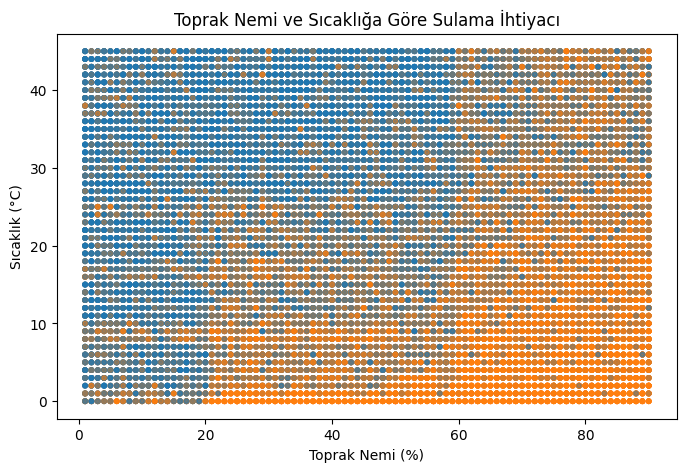

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
renkler = df['sulama_gerekli'].map({'Evet': 'tab:blue', 'Hayır': 'tab:orange'})
plt.scatter(df['Soil Moisture'], df['Temperature'], c=renkler, alpha=0.3, s=10)
plt.xlabel('Toprak Nemi (%)')
plt.ylabel('Sıcaklık (°C)')
plt.title('Toprak Nemi ve Sıcaklığa Göre Sulama İhtiyacı')
plt.show()

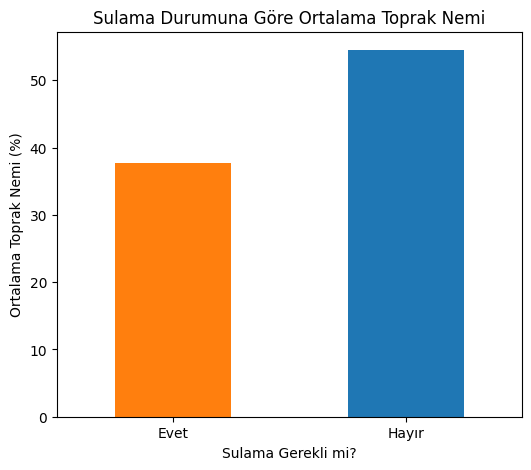

In [ ]:
ortalama_nem = df.groupby('sulama_gerekli')['Soil Moisture'].mean()

plt.figure(figsize=(6,5))
ortalama_nem.plot(kind='bar', color=['tab:orange', 'tab:blue'])
plt.xlabel('Sulama Gerekli mi?')
plt.ylabel('Ortalama Toprak Nemi (%)')
plt.title('Sulama Durumuna Göre Ortalama Toprak Nemi')
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Aşama 3: Model Kurma ve Eğitme

In [ ]:
from sklearn.model_selection import train_test_split

X = df[['Soil Moisture', 'Temperature', 'Soil Humidity']]
y = df['sulama_gerekli']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Eğitim seti:", X_train.shape)
print("Test seti:", X_test.shape)

Eğitim seti: (80000, 3)
Test seti: (20000, 3)


In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

print("Model eğitildi.")

Model eğitildi.


In [ ]:
# Aşama 4: Tahmin ve Değerlendirme

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

dogruluk = accuracy_score(y_test, y_pred)
print(f"Doğruluk (Accuracy): {dogruluk:.2%}")
print()
print(classification_report(y_test, y_pred))

Doğruluk (Accuracy): 71.80%

              precision    recall  f1-score   support

        Evet       0.74      0.73      0.74     10695
       Hayır       0.70      0.70      0.70      9305

    accuracy                           0.72     20000
   macro avg       0.72      0.72      0.72     20000
weighted avg       0.72      0.72      0.72     20000



In [ ]:
import pandas as pd

yeni_ornekler = pd.DataFrame({
    'Soil Moisture': [15, 60, 40],
    'Temperature':   [35, 15, 24],
    'Soil Humidity': [30, 55, 45]
})

tahminler = model.predict(yeni_ornekler)

yeni_ornekler['tahmin_sulama_gerekli'] = tahminler
yeni_ornekler

,Soil Moisture,Temperature,Soil Humidity,tahmin_sulama_gerekli
0,15,35,30,Evet
1,60,15,55,Hayır
2,40,24,45,Evet


In [ ]:
# Eğitim setindeki başarıyı da ölçelim, test ile karşılaştıralım
egitim_dogruluk = model.score(X_train, y_train)
test_dogruluk = model.score(X_test, y_test)

print(f"Eğitim doğruluğu: {egitim_dogruluk:.2%}")
print(f"Test doğruluğu:   {test_dogruluk:.2%}")

Eğitim doğruluğu: 72.25%
Test doğruluğu:   71.80%


In [ ]:
# Aşama 5: Akıllı Tahmin Aracı

In [ ]:
def tahmin_et(toprak_nemi, sicaklik, toprak_nem_orani):
    girdi = pd.DataFrame({
        'Soil Moisture': [toprak_nemi],
        'Temperature': [sicaklik],
        'Soil Humidity': [toprak_nem_orani]
    })
    sonuc = model.predict(girdi)[0]

    if sonuc == 'Evet':
        print(f"🚿 Sonuç: Toprak nemi %{toprak_nemi}, sıcaklık {sicaklik}°C iken SULAMA GEREKLİ.")
    else:
        print(f"✅ Sonuç: Toprak nemi %{toprak_nemi}, sıcaklık {sicaklik}°C iken sulamaya gerek yok.")

    return sonuc

In [ ]:
print("=== Akıllı Sulama Tahmin Aracı ===")
nem = float(input("Toprak nemi (%): "))
sicaklik = float(input("Sıcaklık (°C): "))
toprak_nem = float(input("Toprak nem oranı (%): "))

tahmin_et(nem, sicaklik, toprak_nem)

=== Akıllı Sulama Tahmin Aracı ===
Toprak nemi (%): 10
Sıcaklık (°C): 20
Toprak nem oranı (%): 5
🚿 Sonuç: Toprak nemi %10.0, sıcaklık 20.0°C iken SULAMA GEREKLİ.


'Evet'